# MS_06 — Smog Episode Analysis (MzWarChrosci)

Identifies the top 5 worst PM2.5 episodes in the 2024 test set (greedy non-overlapping
peak-finding on 24h rolling mean). For each episode, overlays actual PM2.5 against all
three architectures — **C1 HGB, C2 CNN-LSTM, C3 shared GNN-LSTM** — at a single forecast
horizon (**h=12**), with BLH on a twin y-axis.

A single horizon keeps the plot legible and puts the three models on equal footing.
Model predictions are aligned to their true forecast-origin timestamps via the
`return_index=True` option of the sequence builders — the sequence datasets drop NaN rows,
so a naive contiguous index slice would misalign the deep models (and silently drop them
from some episode windows). The C2 CNN-LSTM checkpoint did not persist its feature scaler,
so it is refit on the training split here (identical to MS_C2) before inference.

Figures saved to `outputs/MzWarChrosci/figures/episodes/`.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch

from src.config import DATA_PATH, TARGET, HORIZONS, WHO_24H_PM25, ALERT_THRESHOLD, SEQ_LEN_LSTM, get_station_paths
from src.data_loader import load_data, train_test_split
from src.feature_engineering import build_feature_matrix, build_sequence_dataset, WEATHER_MODE_PERFECT_FULL
from src.models.gnn_stacking import (
    build_gnn_sequence_dataset, predict_gnn_lstm, build_gnn_lstm_model, build_adjacency_matrix,
)
from src.models.hybrid_lstm import load_cnn_lstm, predict_cnn_lstm
from src.evaluation import compute_metrics
from src.utils import ensure_dirs

WEATHER_MODE = WEATHER_MODE_PERFECT_FULL
HZ = 12  # single forecast horizon shown for every model

paths = get_station_paths(TARGET)
episodes_dir = paths['figures'] / 'episodes'
ensure_dirs(episodes_dir)

print(f'TARGET: {TARGET} | horizon shown: h={HZ}')
print(f'Episode figures: {episodes_dir}')

TARGET: MzWarChrosci | horizon shown: h=12
Episode figures: D:\MOJE\PROJEKTY\warsaw_aq_forecast\outputs\MzWarChrosci\figures\episodes


In [2]:
df = load_data(DATA_PATH)
train_df, test_df = train_test_split(df)  # train_df needed to refit the C2 scaler
print(f'Train: {len(train_df):,} rows | Test: {len(test_df):,} rows '
      f'({test_df.index.min()} → {test_df.index.max()})')

12:29:14 | src.data_loader | INFO | Loading data from D:\MOJE\PROJEKTY\warsaw_aq_forecast\data\raw\FINAL_merged_PM25_1g_all_seasons.csv


12:29:15 | src.data_loader | INFO | Missing values per column:
MzOtwoBrzozo    1084
MzWarWokalna    2028
MzWarAlNiepo     575
MzLegZegrzyn    1511
MzPiasPulask    1002
MzWarChrosci     416
MzWarBajkowa     636
dir_48            48
dir_24            48


12:29:15 | src.data_loader | INFO | Loaded 52608 rows, 27 columns, range 2019-01-01 00:00:00 → 2024-12-31 23:00:00


12:29:15 | src.data_loader | INFO | Train: 43824 rows (2019-01-01 00:00:00 → 2023-12-31 23:00:00)


12:29:15 | src.data_loader | INFO | Test : 8784 rows (2024-01-01 00:00:00 → 2024-12-31 23:00:00)


Train: 43,824 rows | Test: 8,784 rows (2024-01-01 00:00:00 → 2024-12-31 23:00:00)


In [3]:
# ── Find top-5 worst episodes via greedy peak-finding on 24h rolling mean ──
N_EPISODES = 5
WINDOW_HOURS = 72
HALF = WINDOW_HOURS // 2

rolling_mean = test_df[TARGET].rolling(24, min_periods=12).mean()
remaining = rolling_mean.copy()
episode_peaks = []

for _ in range(N_EPISODES):
    if remaining.dropna().empty:
        break
    peak_idx = remaining.idxmax()
    episode_peaks.append(peak_idx)
    mask = (
        (remaining.index >= peak_idx - pd.Timedelta(hours=HALF)) &
        (remaining.index <= peak_idx + pd.Timedelta(hours=HALF))
    )
    remaining[mask] = -np.inf

print('Top episode peaks:')
for ep_i, peak in enumerate(episode_peaks, 1):
    print(f'  Episode {ep_i}: {peak} — PM2.5={test_df.loc[peak, TARGET]:.1f} µg/m³')

Top episode peaks:
  Episode 1: 2024-01-10 18:00:00 — PM2.5=39.5 µg/m³
  Episode 2: 2024-11-06 20:00:00 — PM2.5=33.3 µg/m³
  Episode 3: 2024-10-27 20:00:00 — PM2.5=43.7 µg/m³
  Episode 4: 2024-12-27 16:00:00 — PM2.5=29.0 µg/m³
  Episode 5: 2024-03-09 07:00:00 — PM2.5=55.3 µg/m³


In [4]:
# ── Load C1_HGB model for h=HZ ───────────────────────────────────────
hgb_model = None
p = paths['models'] / f'hgb_pfxf_h{HZ}.pkl'
if p.exists():
    hgb_model = joblib.load(p)
    print(f'Loaded HGB h={HZ} from {p}')
else:
    print(f'[WARN] HGB h={HZ} not found at {p}')

Loaded HGB h=12 from D:\MOJE\PROJEKTY\warsaw_aq_forecast\outputs\MzWarChrosci\models\hgb_pfxf_h12.pkl


In [5]:
# ── Build the h=HZ prediction series for each model, aligned to true timestamps ──
preds_by_model = {}  # 'C1_HGB' / 'C2_CNN' / 'C3_GNN' -> pd.Series indexed by timestamp

# C1 HGB (tabular): build_feature_matrix already returns a DataFrame indexed by timestamp.
if hgb_model is not None:
    X_te, _ = build_feature_matrix(test_df, horizon=HZ, weather_mode=WEATHER_MODE)
    preds_by_model['C1_HGB'] = pd.Series(
        hgb_model.predict(X_te.values), index=X_te.index, name=f'C1_HGB_h{HZ}')
    print(f'C1_HGB h={HZ}: {len(X_te)} preds')

12:29:15 | src.feature_engineering | INFO | build_feature_matrix | horizon=12 | weather_mode=perfect_forecast_full


12:29:16 | src.feature_engineering | INFO | perfect_forecast_full: shifted 8 MET + 10 HYSPLIT_NUM + 2 HYSPLIT_CAT by -12 h


12:29:16 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols


12:29:16 | src.feature_engineering | INFO | Retaining 10 HYSPLIT numeric columns


12:29:16 | src.feature_engineering | INFO |   X: (7780, 45) | y mean=12.62, y std=8.37


C1_HGB h=12: 7780 preds


In [6]:
# ── C2 CNN-LSTM and C3 shared GNN-LSTM: aligned h=HZ predictions ──────
hz_idx = HZ - 1

# --- C2 CNN-LSTM ---------------------------------------------------------
# The C2 checkpoint did not save its feature scaler, so refit it on train (exactly
# as MS_C2 did: fit on train, apply to test) before inference.
cnn_path = paths['models'] / 'cnn_lstm_pfx_model.pt'
if cnn_path.exists():
    cnn_model = load_cnn_lstm(cnn_path)
    cnn_ckpt = torch.load(cnn_path, map_location='cpu', weights_only=False)
    seq_len_cnn = cnn_ckpt['seq_len']
    _, _, _, scaler_cnn = build_sequence_dataset(
        train_df, seq_len=seq_len_cnn, horizons=HORIZONS,
        weather_mode=WEATHER_MODE, fit_scaler=True)
    X_cnn, _, _, _, idx_cnn = build_sequence_dataset(
        test_df, seq_len=seq_len_cnn, horizons=HORIZONS,
        weather_mode=WEATHER_MODE, scaler_X=scaler_cnn, return_index=True)
    cnn_preds = predict_cnn_lstm(cnn_model, X_cnn)  # (n, 24) µg/m³ — expm1 applied inside
    preds_by_model['C2_CNN'] = pd.Series(cnn_preds[:, hz_idx], index=idx_cnn, name=f'C2_CNN_h{HZ}')
    print(f'C2_CNN h={HZ}: {len(idx_cnn)} preds (scaler refit on train)')
else:
    print(f'[WARN] CNN-LSTM not found at {cnn_path} — C2 omitted')

# --- C3 shared GNN-LSTM --------------------------------------------------
gnn_path = paths['models'] / 'gnn_lstm_shared_pfxf_model.pt'
if gnn_path.exists():
    import src.models.gnn_stacking as gs
    ckpt = torch.load(gnn_path, map_location='cpu', weights_only=False)
    gs.ALL_STATIONS_ORDERED = list(ckpt['all_stations'])
    k = ckpt['all_stations'].index(TARGET)
    gnn_model = build_gnn_lstm_model(
        ckpt['n_nodes'], ckpt['n_node_features'], ckpt['seq_len'], ckpt['n_horizons'])
    gnn_model.load_state_dict(ckpt['model_state'])
    gnn_model.eval()
    A_static = ckpt.get('A_static', build_adjacency_matrix())

    X_gnn, _, _, _, idx_gnn = build_gnn_sequence_dataset(
        test_df, seq_len=ckpt['seq_len'], horizons=HORIZONS,
        weather_mode=WEATHER_MODE, scaler=ckpt.get('scaler'), return_index=True)
    gnn_preds = predict_gnn_lstm(gnn_model, X_gnn, A_static)[:, k, :]  # (n, 24) for TARGET node
    preds_by_model['C3_GNN'] = pd.Series(gnn_preds[:, hz_idx], index=idx_gnn, name=f'C3_GNN_h{HZ}')
    print(f'C3_GNN h={HZ}: {len(idx_gnn)} preds | TARGET node k={k}')
else:
    print(f'[WARN] GNN not found at {gnn_path} — C3 omitted')

print('Models available:', list(preds_by_model))

12:29:18 | src.feature_engineering | INFO | build_sequence_dataset | seq_len=48 | weather_mode=perfect_forecast_full


12:29:18 | src.feature_engineering | INFO | perfect_forecast_full: shifted 8 MET + 10 HYSPLIT_NUM + 2 HYSPLIT_CAT by -24 h


12:29:18 | src.feature_engineering | INFO | One-hot encoded HYSPLIT categoricals: ['dir_48', 'dir_24'] → 8 dummy cols


12:29:18 | src.feature_engineering | INFO | Retaining 10 HYSPLIT numeric columns


12:29:19 | src.feature_engineering | INFO | Sequence dataset: X=(37879, 48, 45), y=(37879, 24), features=45


...

12:29:23 | src.feature_engineering | INFO | Retaining 10 HYSPLIT numeric columns


12:29:23 | src.models.gnn_stacking | INFO | build_gnn_sequence_dataset | seq_len=48 | weather_mode=perfect_forecast_full | fit_scaler=False


C2_CNN h=12: 7709 preds (scaler refit on train)


12:29:24 | src.models.gnn_stacking | INFO | GNN sequences: X=(6349, 48, 7, 35) y=(6349, 7, 24) | n_node_features=35 | n_nodes=7


C3_GNN h=12: 6349 preds | TARGET node k=0
Models available: ['C1_HGB', 'C2_CNN', 'C3_GNN']


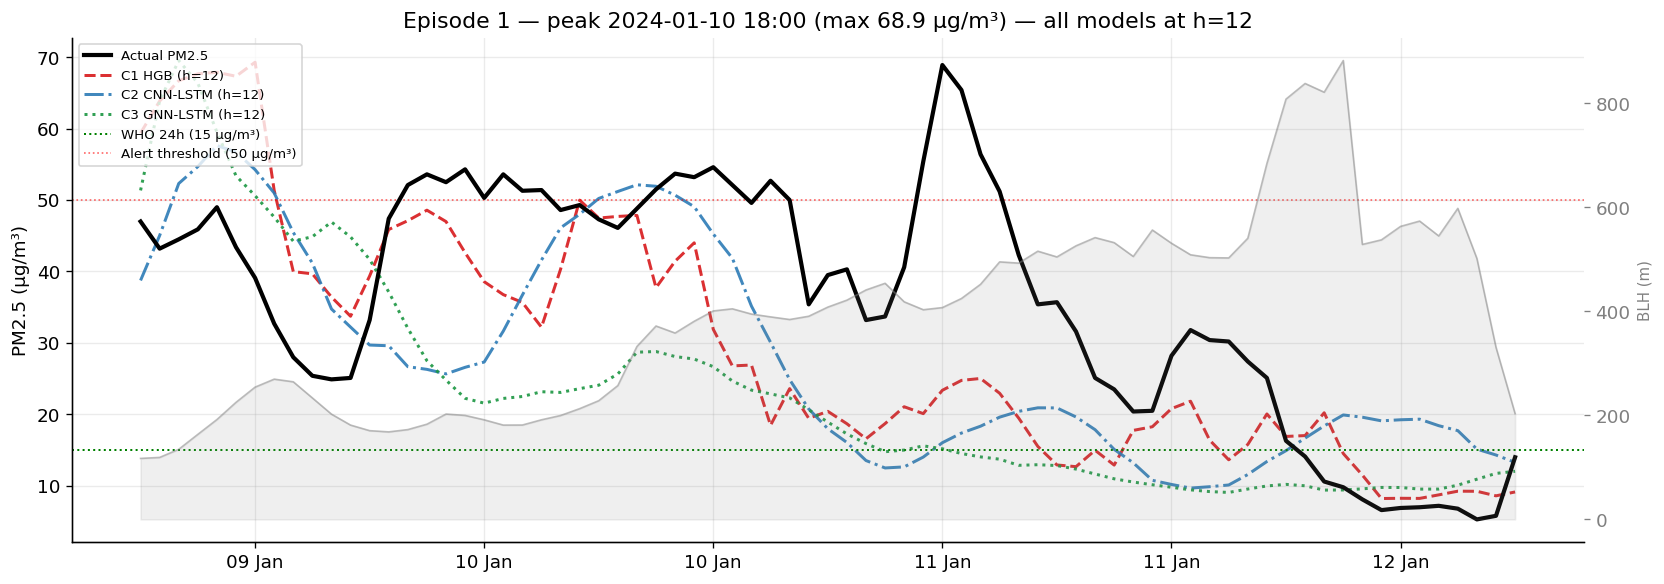

Episode 1 saved → D:\MOJE\PROJEKTY\warsaw_aq_forecast\outputs\MzWarChrosci\figures\episodes\episode_1.png


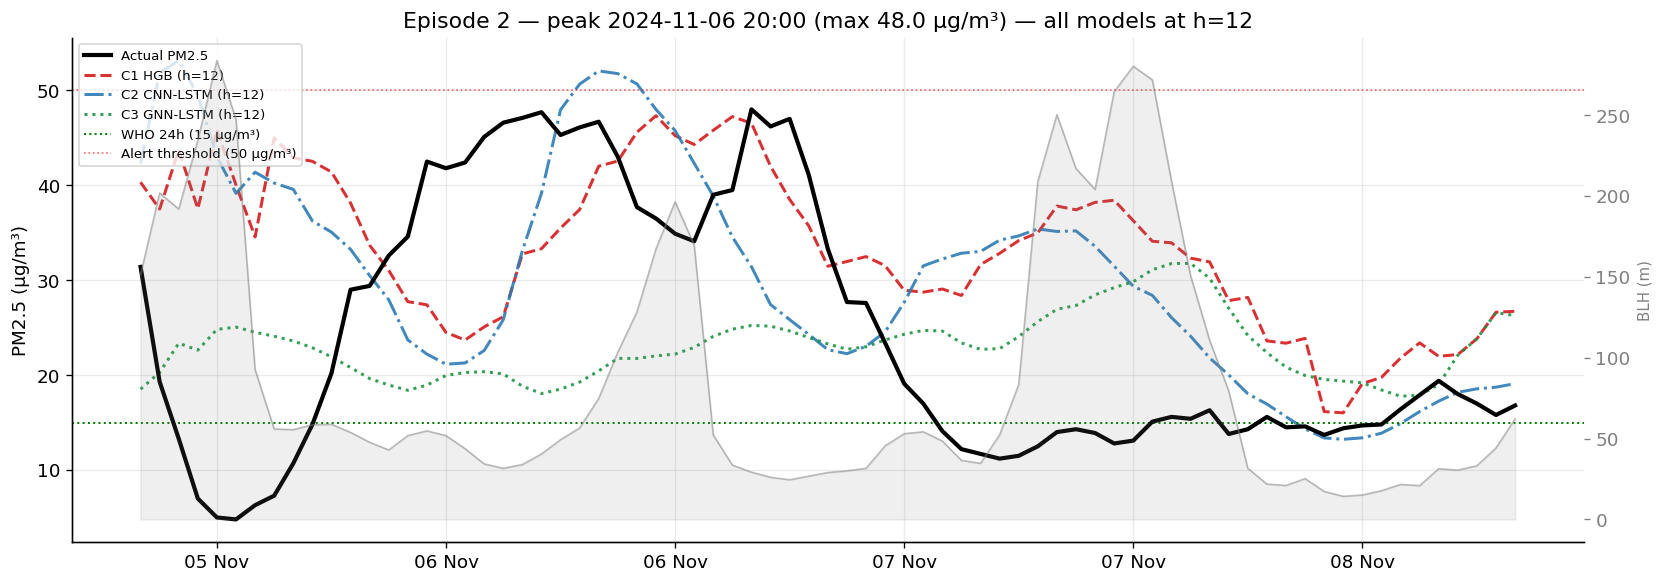

Episode 2 saved → D:\MOJE\PROJEKTY\warsaw_aq_forecast\outputs\MzWarChrosci\figures\episodes\episode_2.png


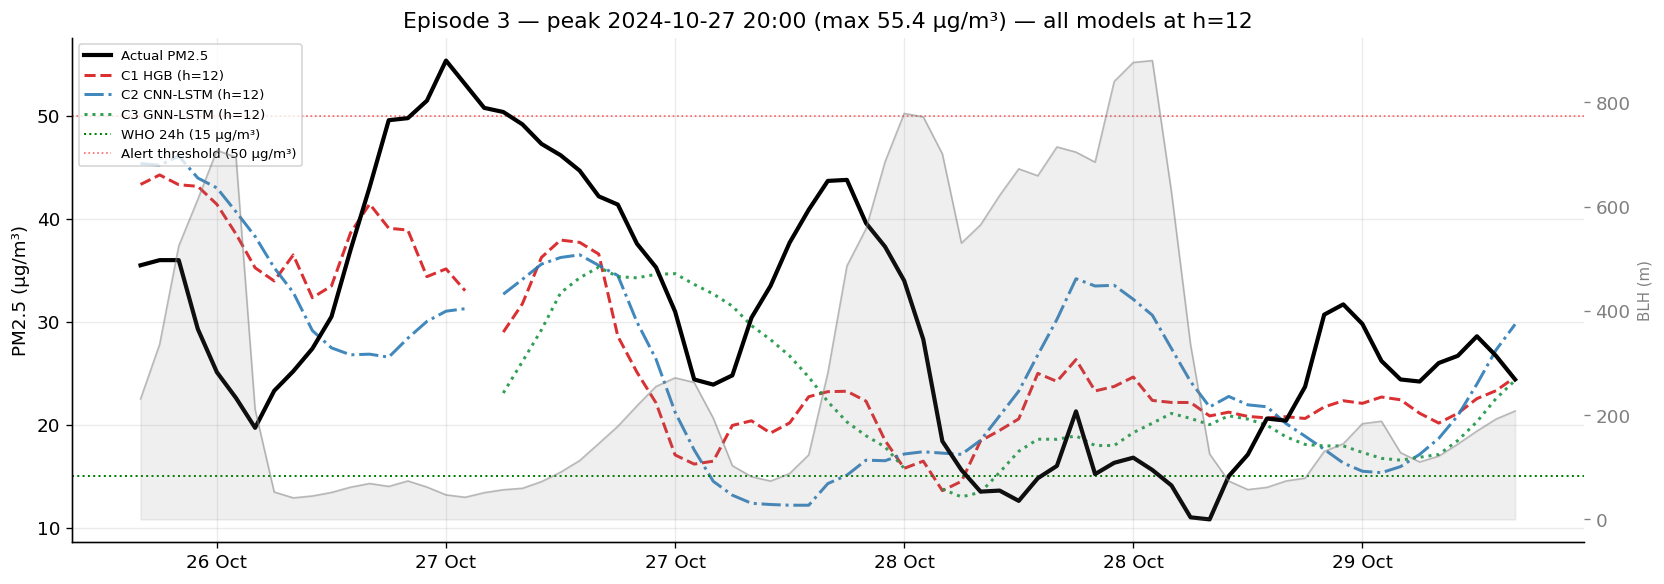

Episode 3 saved → D:\MOJE\PROJEKTY\warsaw_aq_forecast\outputs\MzWarChrosci\figures\episodes\episode_3.png


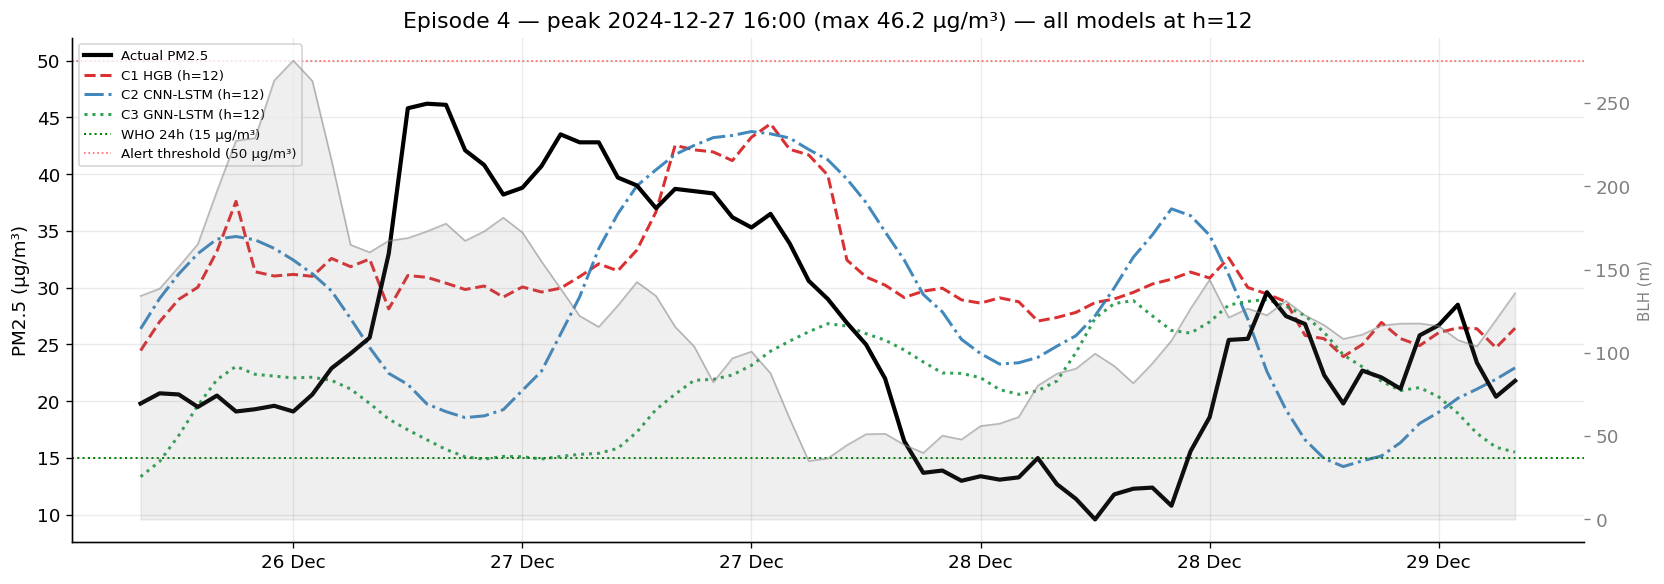

Episode 4 saved → D:\MOJE\PROJEKTY\warsaw_aq_forecast\outputs\MzWarChrosci\figures\episodes\episode_4.png


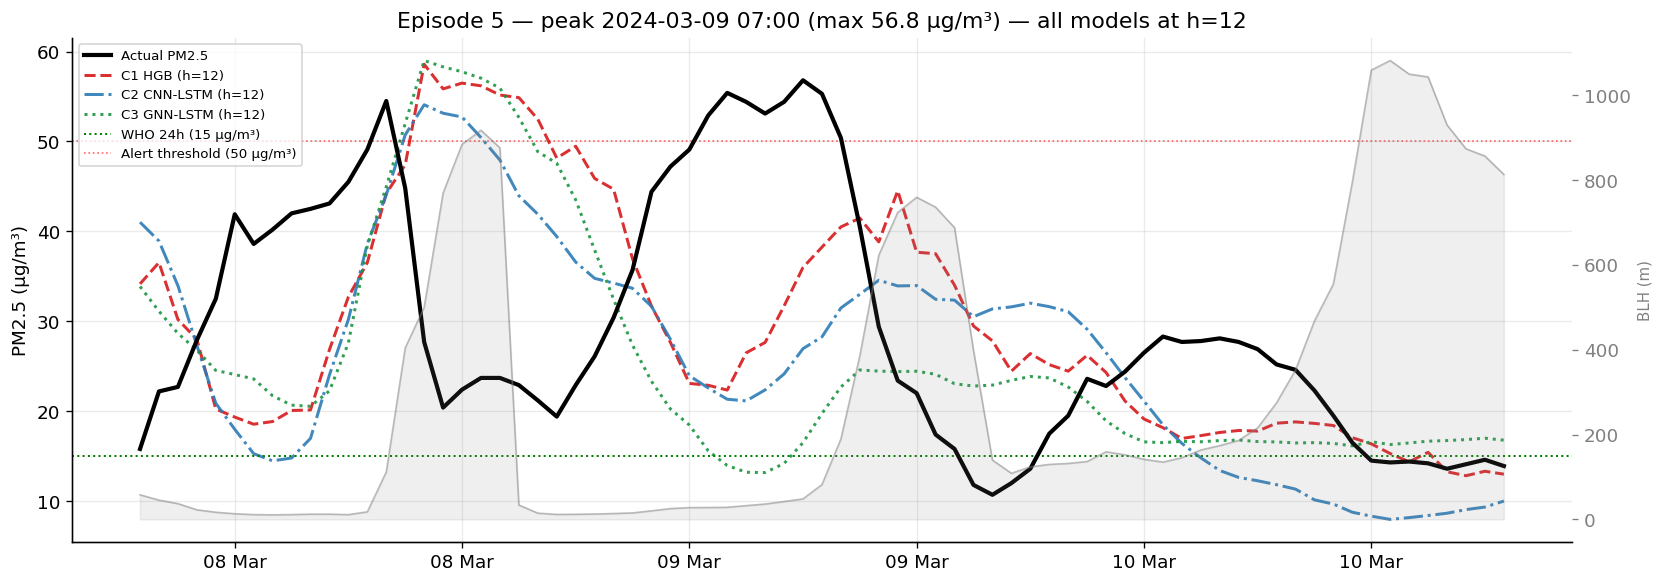

Episode 5 saved → D:\MOJE\PROJEKTY\warsaw_aq_forecast\outputs\MzWarChrosci\figures\episodes\episode_5.png


In [7]:
# ── Episode figures: all three models at h=HZ ────────────────────────
summary_rows = []

# (model_key, legend label, line style, color)
MODEL_STYLE = [
    ('C1_HGB', 'C1 HGB',      '--', '#d7191c'),
    ('C2_CNN', 'C2 CNN-LSTM', '-.', '#2c7bb6'),
    ('C3_GNN', 'C3 GNN-LSTM', ':',  '#1a9641'),
]

for ep_i, peak in enumerate(episode_peaks, 1):
    start = peak - pd.Timedelta(hours=HALF)
    end   = peak + pd.Timedelta(hours=HALF)
    mask  = (test_df.index >= start) & (test_df.index <= end)

    actual = test_df.loc[mask, TARGET]
    blh    = test_df.loc[mask, 'blh'] if 'blh' in test_df.columns else None

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(actual.index, actual.values, color='black', linewidth=2.5,
            label='Actual PM2.5', zorder=5)

    for key, label, ls, color in MODEL_STYLE:
        if key not in preds_by_model:
            continue
        ep_preds = preds_by_model[key].reindex(actual.index)
        if ep_preds.notna().sum() == 0:
            continue  # no coverage in this window
        ax.plot(ep_preds.index, ep_preds.values, linestyle=ls, color=color,
                linewidth=1.8, label=f'{label} (h={HZ})', alpha=0.9)
        valid = actual.notna() & ep_preds.notna()
        if valid.any():
            m = compute_metrics(actual[valid].values, ep_preds[valid].values)
            summary_rows.append({'Episode': ep_i, 'Peak': peak, 'Model': key, 'Horizon': HZ,
                                 **m, 'max_obs': actual.max(), 'max_pred': ep_preds.max()})

    # BLH on twin y-axis (muted)
    if blh is not None and blh.notna().any():
        ax2 = ax.twinx()
        ax2.fill_between(blh.index, blh.values, alpha=0.12, color='grey')
        ax2.plot(blh.index, blh.values, color='grey', linewidth=1.0, alpha=0.5, label='BLH')
        ax2.set_ylabel('BLH (m)', color='grey', fontsize=9)
        ax2.tick_params(axis='y', colors='grey')

    ax.axhline(WHO_24H_PM25, color='green', linestyle=':', linewidth=1.2,
               label=f'WHO 24h ({WHO_24H_PM25} µg/m³)')
    ax.axhline(ALERT_THRESHOLD, color='red', linestyle=':', linewidth=1.0,
               label=f'Alert threshold ({ALERT_THRESHOLD} µg/m³)', alpha=0.6)

    ax.set_ylabel('PM2.5 (µg/m³)')
    ax.set_title(f'Episode {ep_i} — peak {peak.strftime("%Y-%m-%d %H:%M")} '
                 f'(max {actual.max():.1f} µg/m³) — all models at h={HZ}')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(alpha=0.25)
    fig.tight_layout()

    save_path = episodes_dir / f'episode_{ep_i}.png'
    fig.savefig(save_path, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f'Episode {ep_i} saved → {save_path}')

In [8]:
# ── Summary table ─────────────────────────────────────────────────────
summary_df = pd.DataFrame(summary_rows)
if not summary_df.empty:
    print(f'\nEpisode x Model summary (h={HZ}):')
    print(summary_df[['Episode', 'Model', 'MAE', 'MBE', 'max_obs', 'max_pred']].to_string(index=False))


# -- Onset detection: predict PM2.5 > ALERT at least 6h before actual onset --
print(f'\n-- Onset detection (h={HZ}): PM2.5 > {ALERT_THRESHOLD} ug/m3 predicted >=6h early --')
for ep_i, peak in enumerate(episode_peaks, 1):
    start = peak - pd.Timedelta(hours=HALF)
    end   = peak + pd.Timedelta(hours=HALF)
    mask  = (test_df.index >= start) & (test_df.index <= end)
    actual = test_df.loc[mask, TARGET]

    rising = actual[actual >= ALERT_THRESHOLD]
    if rising.empty:
        print(f'  Episode {ep_i}: PM2.5 never exceeds {ALERT_THRESHOLD} ug/m3 in window')
        continue
    actual_onset = rising.index[0]

    for key, label, _, _ in MODEL_STYLE:
        if key not in preds_by_model:
            continue
        p = preds_by_model[key].reindex(actual.index)
        early_window = p[p.index <= actual_onset - pd.Timedelta(hours=6)]
        predicted_early = (early_window >= ALERT_THRESHOLD).any()
        status = 'YES' if predicted_early else 'no'
        print(f'  Episode {ep_i} | {label} h={HZ}: onset predicted >=6h early? {status}')


Episode x Model summary (h=12):
 Episode  Model     MAE      MBE  max_obs  max_pred
       1 C1_HGB 13.6456  -6.5242     68.9 69.294173
       1 C2_CNN 14.9514  -8.2262     68.9 57.630817
       1 C3_GNN 19.2631 -12.9430     68.9 69.528961
       2 C1_HGB 13.8570   9.0997     48.0 47.333666
       2 C2_CNN 13.1621   6.2639     48.0 53.144108
       2 C3_GNN 13.1854  -1.2132     48.0 31.780407
       3 C1_HGB  9.5105  -3.1523     55.4 44.280587
       3 C2_CNN 12.4306  -3.9166     55.4 46.115250
       3 C3_GNN  8.4092  -5.0875     55.4 35.316227
       4 C1_HGB  9.3765   5.0651     46.2 44.428572
       4 C2_CNN 11.4216   2.7274     46.2 43.750072
       4 C3_GNN 10.5267  -4.3783     46.2 28.961088
       5 C1_HGB 14.2193   0.2493     56.8 58.585079
       5 C2_CNN 15.5870  -3.0095     56.8 54.079895
       5 C3_GNN 15.2298  -3.6744     56.8 58.997227

-- Onset detection (h=12): PM2.5 > 50 ug/m3 predicted >=6h early --
  Episode 1 | C1 HGB h=12: onset predicted >=6h early? YES
  Episo